In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import xgboost as xgb
import optuna
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve, auc

In [84]:
df = pd.read_csv("data/credit_card_fraud_2026.csv")

df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,11,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,12,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,13,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,14,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,15,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


# 1. Exploratory Data Analysis

## 1.1 Data Inspection

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [86]:
df.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10010.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,11.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5010.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10010.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15010.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20010.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [87]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values: 0
Duplicate rows: 0


In [88]:
print("Target Distribution:")
display(df['is_fraud'].value_counts().to_frame("Count"))

Target Distribution:


,Count
is_fraud,
0,19661
1,339


In [89]:
print("Target Percentage")
display((df['is_fraud'].value_counts(normalize=True)*100).round(2).to_frame("Percentage"))

Target Percentage


,Percentage
is_fraud,
0,98.3
1,1.7


## 1.2 Univariate Analysis

In [90]:
numerical_cols = [
    'amount_usd',
    'hours_since_last_txn',
    'txn_count_last_24h',
    'distance_from_home_km',
    'card_age_months',
    'customer_age',
    'account_balance_usd',
    'velocity_score',
    'merchant_risk_score',
    'prior_disputes'
]

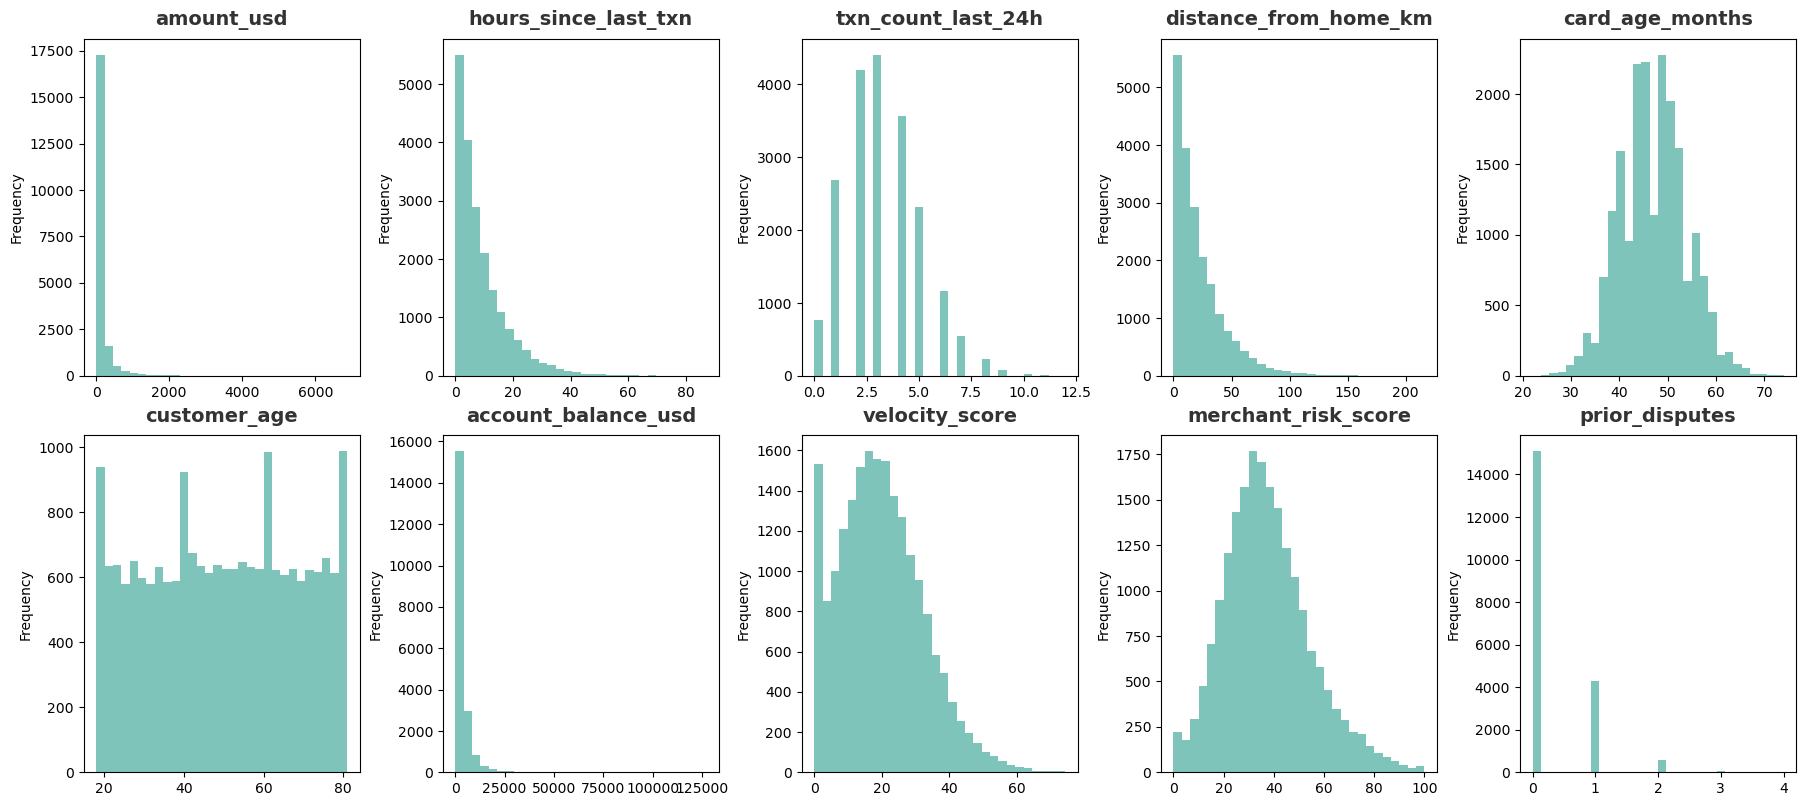

In [91]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 8))
axes = axes.flatten()

plot_color = "#2A9D8F"

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        ax=axes[i],
        color=plot_color,
        bins=30,
        alpha=0.6,
        edgecolor=None
    )

    axes[i].set_title(col, fontsize=14, fontweight='bold', pad=10, color='#333333')
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_xlabel("")

plt.tight_layout(pad=0.5)

plt.show()

In [92]:
categorical_cols = df.select_dtypes(include=['object', 'bool'])

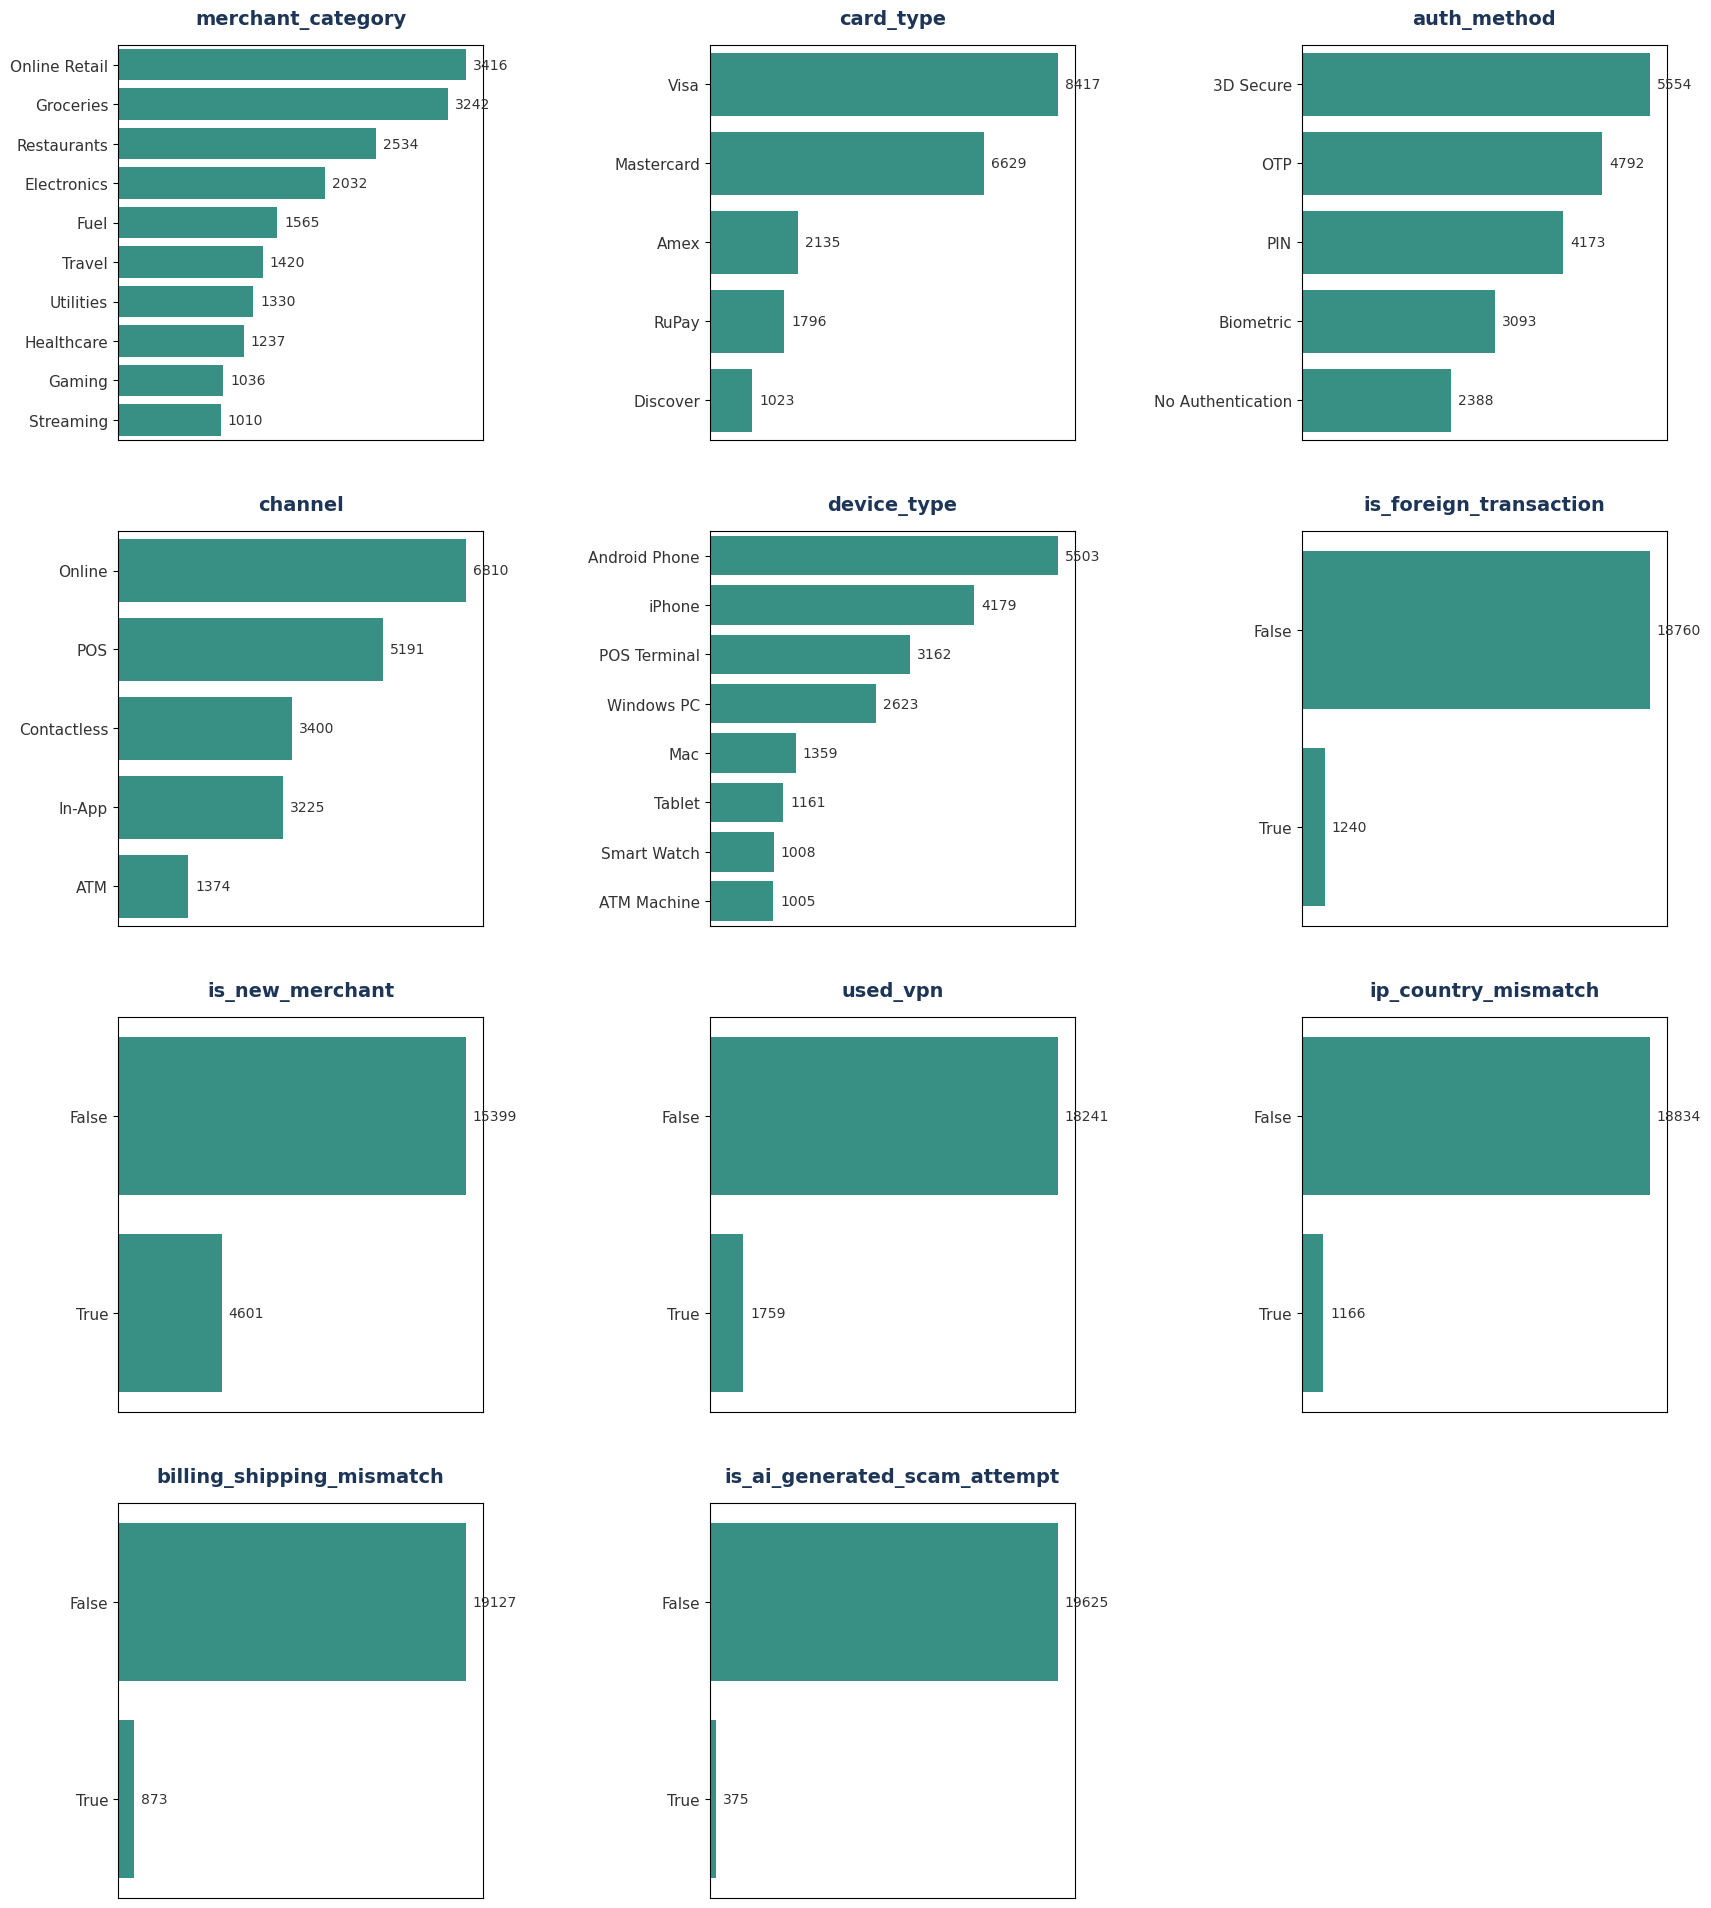

In [93]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts().head(10)
    sns.barplot(
        x=value_counts.values, 
        y=value_counts.index, 
        ax=axes[i], 
        color=plot_color,
        orient='h' # 'h' cho horizontal
    )

    for container in axes[i].containers:
        axes[i].bar_label(container, padding=5, fontsize=10, color="#333333")

    axes[i].set_title(col, fontsize=14, fontweight='bold', pad=15, color="#1d3557")
    axes[i].set_xlabel('') # Bỏ tên trục X
    axes[i].set_ylabel('') # Bỏ tên trục Y

    axes[i].set_xticks([])
    axes[i].tick_params(axis='y', labelsize=11, labelcolor="#333333")

axes[-1].set_visible(False)

plt.tight_layout(pad=4.0)

plt.show()

## 1.3 Bivariate and Mulitvariate Analysis

### Linear Correlation

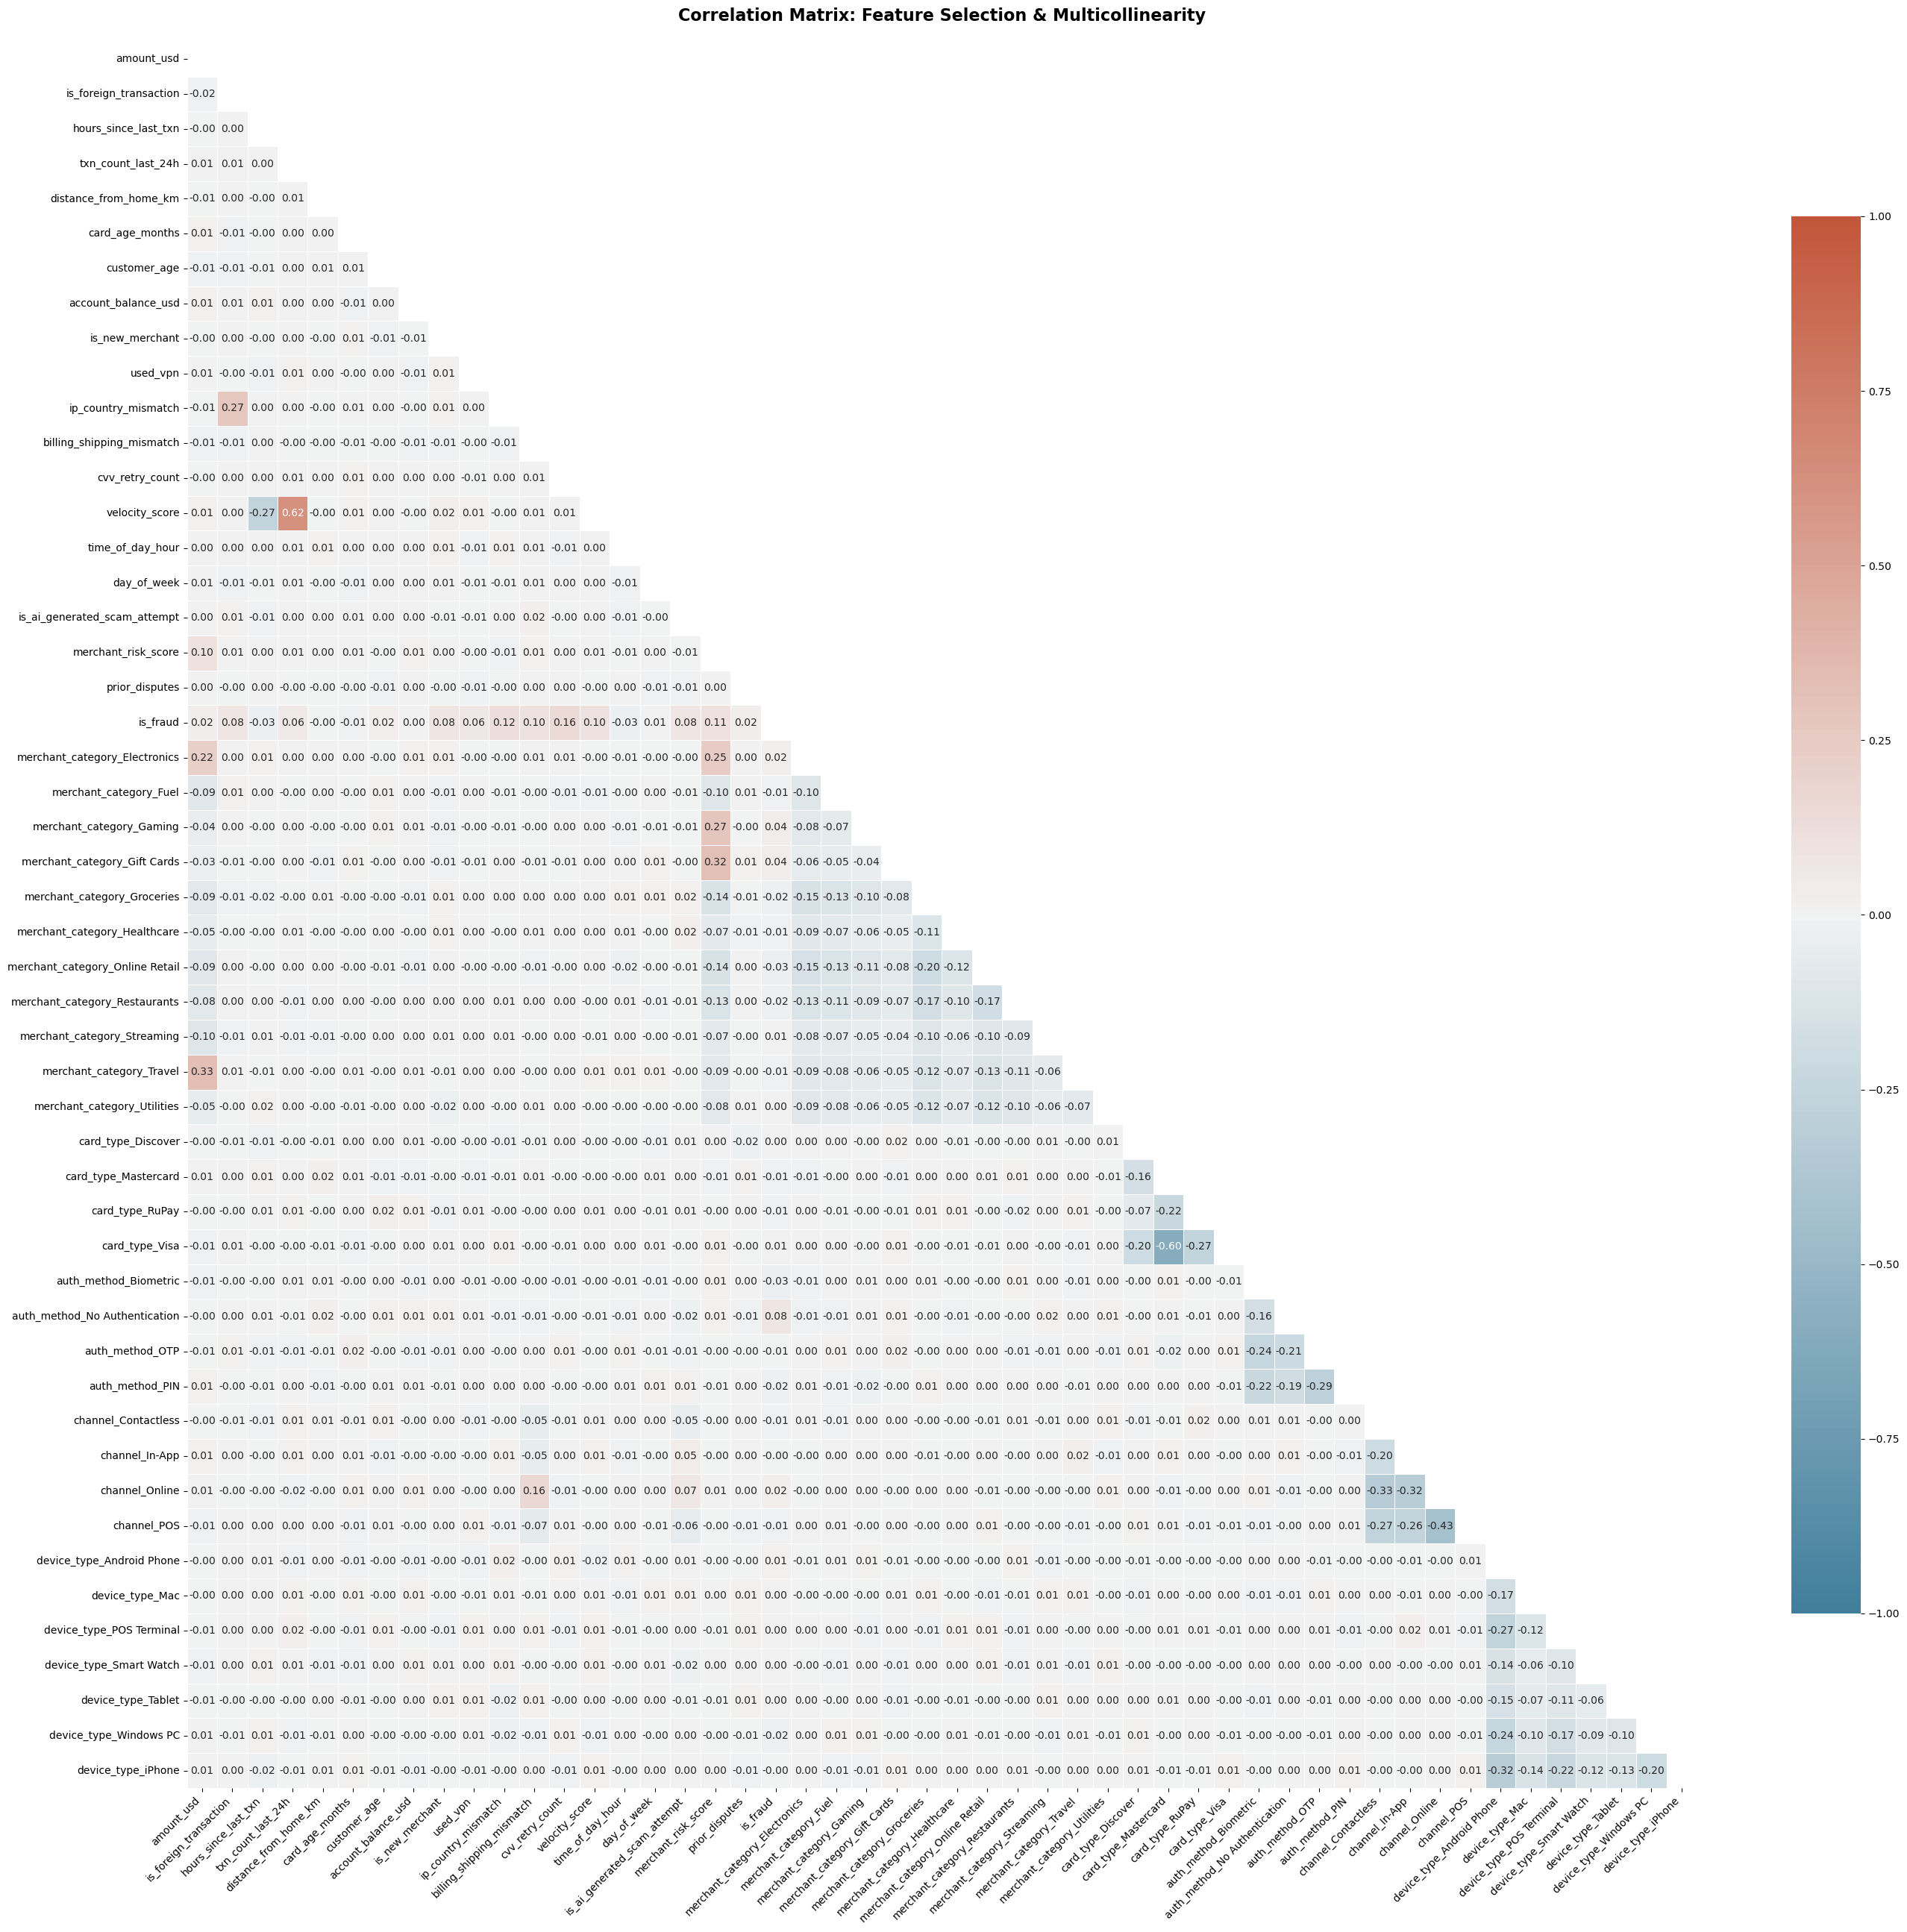

In [94]:
df_processed = df.copy()
bool_cols = df.select_dtypes(include=['bool'])
for col in bool_cols:
    df_processed[col] = df_processed[col].astype(int)

df_processed = pd.get_dummies(df_processed, columns=df.select_dtypes(include=['object']).columns, drop_first=True)
df_processed = df_processed.drop(columns=['transaction_id'])
corr_matrix = df_processed.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(28, 26))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, vmin=-1.0, # Cố định thang đo từ -1 đến 1
    center=0,            # Tâm là 0 (màu trắng)
    annot=True,          # Hiện con số
    fmt=".2f",           # Lấy 2 chữ số thập phân
    linewidths=.5,       # Tạo đường viền mảnh giữa các ô
    cbar_kws={"shrink": .8}, # Thu nhỏ thanh màu bên cạnh một chút
    annot_kws={"size": 10}   # Chỉnh size chữ số trong ô
)

plt.title('Correlation Matrix: Feature Selection & Multicollinearity', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [95]:
corr_matrix

,amount_usd,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,...,channel_In-App,channel_Online,channel_POS,device_type_Android Phone,device_type_Mac,device_type_POS Terminal,device_type_Smart Watch,device_type_Tablet,device_type_Windows PC,device_type_iPhone
amount_usd,1.000000,-0.015337,-0.004697,0.006365,-0.005460,0.012348,-0.010271,0.009512,-0.001179,0.005207,...,0.009441,0.006970,-0.009460,-0.002987,-0.003847,-0.006842,-0.010493,-0.005295,0.005339,0.007491
is_foreign_transaction,-0.015337,1.000000,0.000599,0.007149,0.001997,-0.012577,-0.009866,0.006638,0.002334,-0.001507,...,0.002847,-0.001409,0.003385,0.000378,0.001435,0.003953,0.003321,-0.004417,-0.005912,0.002500
hours_since_last_txn,-0.004697,0.000599,1.000000,0.000508,-0.002970,-0.001885,-0.006366,0.007882,-0.004287,-0.011087,...,-0.002984,-0.000317,0.004493,0.005384,0.001132,0.004089,0.010643,-0.000759,0.008168,-0.018882
txn_count_last_24h,0.006365,0.007149,0.000508,1.000000,0.006385,0.002571,0.001216,0.000606,0.002218,0.012191,...,0.012525,-0.015365,0.000971,-0.008786,0.010891,0.017175,0.007554,-0.001983,-0.009297,-0.005522
distance_from_home_km,-0.005460,0.001997,-0.002970,0.006385,1.000000,0.004566,0.005347,0.002393,-0.001348,0.001617,...,0.000874,-0.001561,0.000348,0.001347,-0.003973,-0.000149,-0.008643,0.003482,-0.006398,0.005415
card_age_months,0.012348,-0.012577,-0.001885,0.002571,0.004566,1.000000,0.005039,-0.008965,0.009853,-0.003812,...,0.006456,0.010527,-0.010765,-0.008673,0.009125,-0.008049,-0.012090,-0.006081,0.002753,0.014336
customer_age,-0.010271,-0.009866,-0.006366,0.001216,0.005347,0.005039,1.000000,0.004879,-0.011685,0.001256,...,-0.012621,0.001303,0.006291,-0.004242,-0.001512,0.008866,0.003068,-0.004349,-0.000087,-0.005562
account_balance_usd,0.009512,0.006638,0.007882,0.000606,0.002393,-0.008965,0.004879,1.000000,-0.005368,-0.008055,...,-0.002042,0.008151,-0.000873,-0.008486,0.009127,-0.001348,0.013908,0.004453,-0.000692,-0.009199
is_new_merchant,-0.001179,0.002334,-0.004287,0.002218,-0.001348,0.009853,-0.011685,-0.005368,1.000000,0.013147,...,-0.000617,0.002346,0.001033,-0.001853,-0.001717,-0.010231,0.005490,0.012657,-0.002612,-0.000403
used_vpn,0.005207,-0.001507,-0.011087,0.012191,0.001617,-0.003812,0.001256,-0.008055,0.013147,1.000000,...,-0.004627,-0.004075,0.014276,-0.008297,-0.007383,0.012050,0.004314,0.010487,0.006959,-0.007618


## 1.4 Outliers Detection

In [96]:
features_to_check = [
    'amount_usd',
    'account_balance_usd',
    'distance_from_home_km',
    'hours_since_last_txn',
    'velocity_score',
    'txn_count_last_24h'
]

In [97]:
X_outlier_check = df_processed[features_to_check]

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X_outlier_check)

df_processed['is_multivariate_outlier'] = outlier_labels
df_processed['is_multivariate_outlier'] = df_processed['is_multivariate_outlier'].map({-1: True, 1: False})

print(df_processed['is_multivariate_outlier'].value_counts())

is_multivariate_outlier
False    19000
True      1000
Name: count, dtype: int64


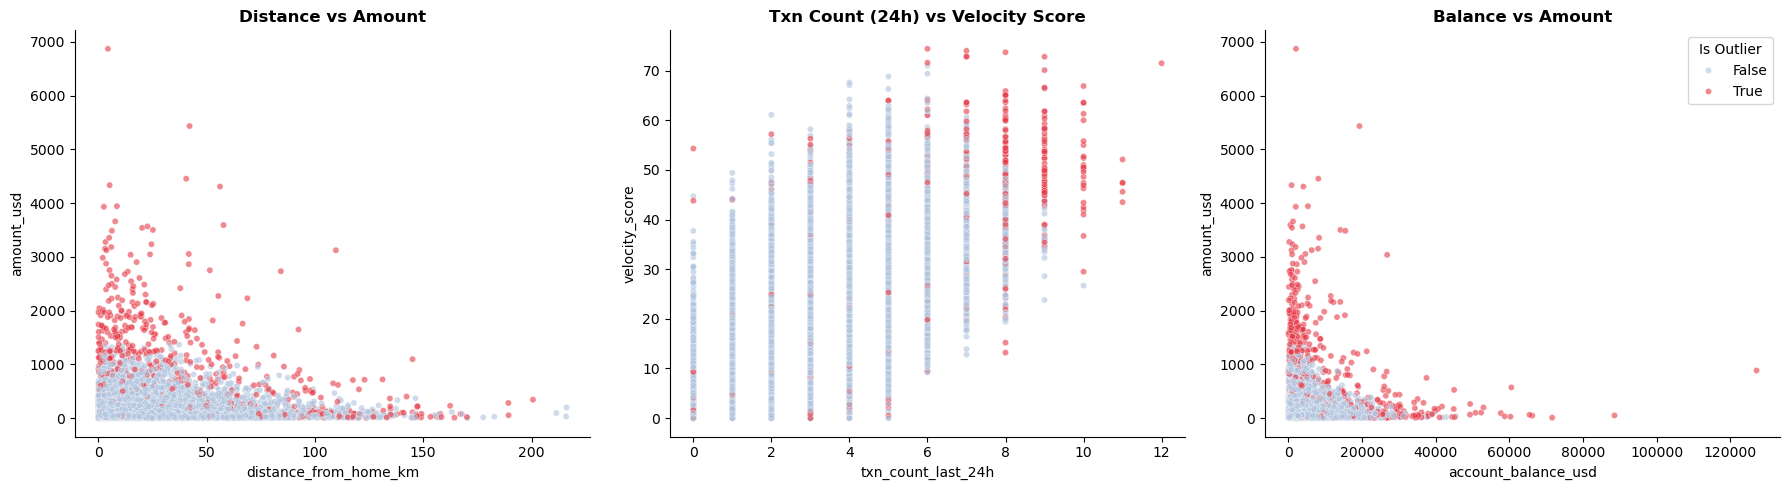

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {False: '#b0c4de', True: '#e63946'}

# Cặp 1
sns.scatterplot(
    data=df_processed, x='distance_from_home_km', y='amount_usd', 
    hue='is_multivariate_outlier', palette=palette, alpha=0.6, s=20, ax=axes[0], legend=False,
    hue_order=[False, True]
)
axes[0].set_title('Distance vs Amount', fontweight='bold')

# Cặp 2
sns.scatterplot(
    data=df_processed, x='txn_count_last_24h', y='velocity_score', 
    hue='is_multivariate_outlier', palette=palette, alpha=0.6, s=20, ax=axes[1], legend=False,
    hue_order=[False, True]
)
axes[1].set_title('Txn Count (24h) vs Velocity Score', fontweight='bold')

# Cặp 3
sns.scatterplot(
    data=df_processed, x='account_balance_usd', y='amount_usd', 
    hue='is_multivariate_outlier', palette=palette, alpha=0.6, s=20, ax=axes[2],
    hue_order=[False, True]
)
axes[2].set_title('Balance vs Amount', fontweight='bold')
axes[2].legend(title='Is Outlier', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

# 2. Data Preprocessing

## 2.1 Split data

In [99]:
X = df_processed.drop(columns=['is_fraud', 'is_multivariate_outlier'])
y = df_processed['is_fraud']

print(f"Number of features: {X.shape[1]}")
print(f"Y label ratio: {y.value_counts(normalize=True)*100}")

Number of features: 49
Y label ratio: is_fraud
0    98.305
1     1.695
Name: proportion, dtype: float64


In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Size of Train set: {X_train.shape[0]} rows")
print(f"Size of Test set: {X_test.shape[0]} rows")

Size of Train set: 16000 rows
Size of Test set: 4000 rows


# 3. Training model

In [101]:
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=ratio, # Kỹ thuật phạt trọng số cực mạnh của XGBoost
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [102]:
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Lowering the threshold for testing (Card is blocked if there is just a 15% suspicion level)
custom_threshold = 0.15
y_pred_tuned_xgb = (y_pred_prob_xgb >= custom_threshold).astype(int)

# 4. Model evaluation

In [103]:
print(classification_report(y_test, y_pred_tuned_xgb))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      3932
           1       0.13      0.54      0.21        68

    accuracy                           0.93      4000
   macro avg       0.56      0.74      0.59      4000
weighted avg       0.98      0.93      0.95      4000



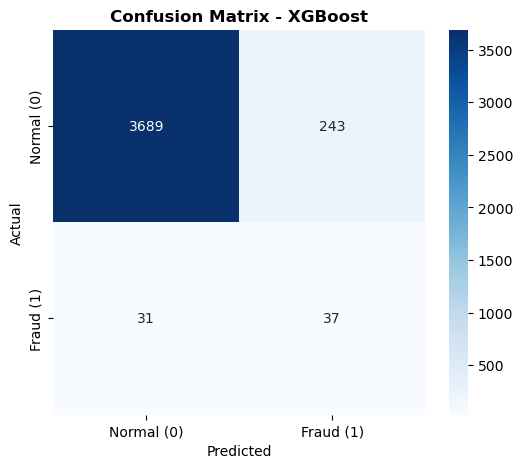

In [104]:
cm = confusion_matrix(y_test, y_pred_tuned_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - XGBoost', fontweight='bold')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9148\1575638853.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title='', fontsize=11, loc='lower right')


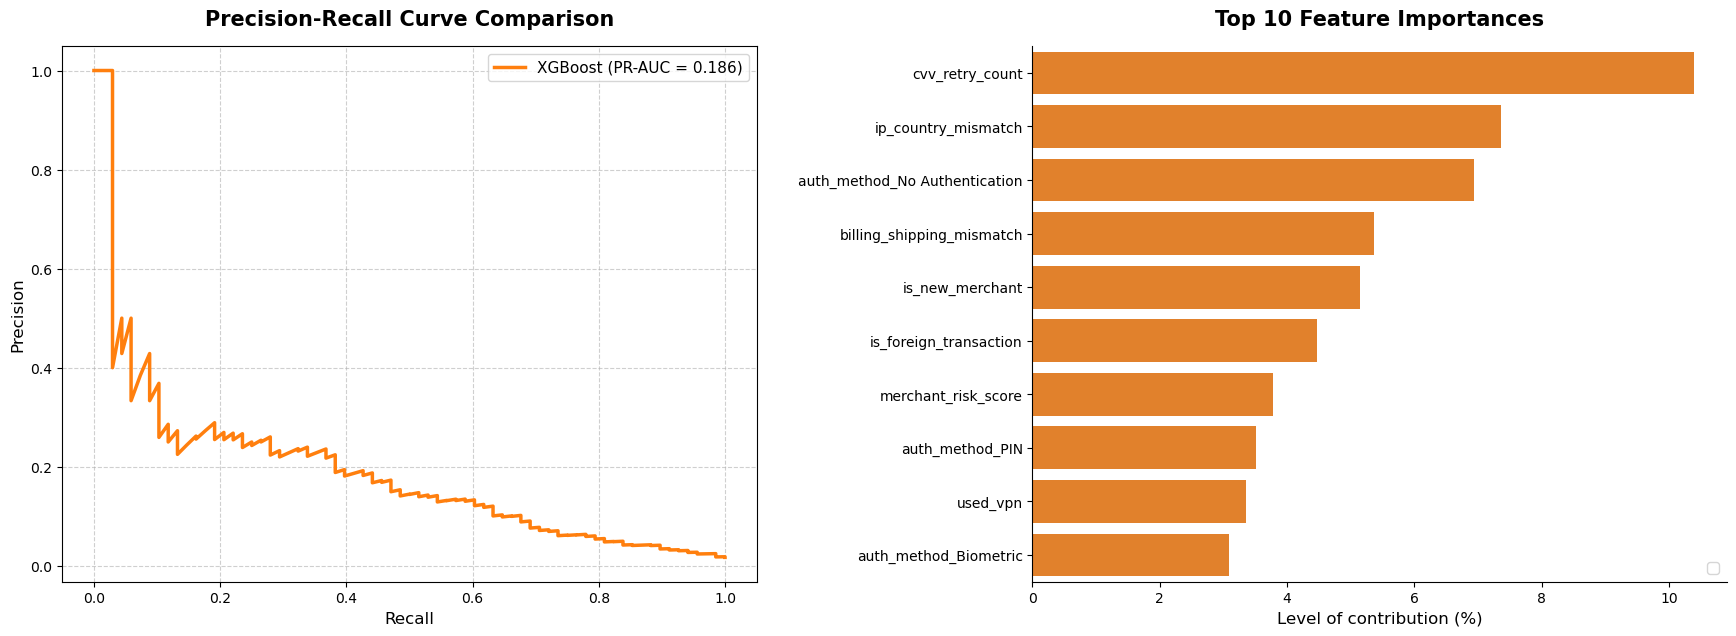

In [105]:
color_xgb = '#ff7f0e'

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, y_pred_prob_xgb)
xgb_pr_auc = auc(xgb_rec, xgb_prec)

axes[0].plot(xgb_rec, xgb_prec, label=f'XGBoost (PR-AUC = {xgb_pr_auc:.3f})', color=color_xgb, lw=2.5)

axes[0].set_title('Precision-Recall Curve Comparison', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].legend(loc='upper right', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

xgb_imp = xgb_model.feature_importances_

xgb_imp_percent = (xgb_imp / xgb_imp.sum()) * 100

df_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Percent': xgb_imp_percent
})
top10_df = df_imp.sort_values(by='Importance_Percent', ascending=False).head(10)

sns.barplot(
    data=top10_df, 
    x='Importance_Percent', 
    y='Feature', 
    ax=axes[1], 
    color=color_xgb
)

axes[1].set_title('Top 10 Feature Importances', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Level of contribution (%)', fontsize=12)
axes[1].set_ylabel('')
axes[1].legend(title='', fontsize=11, loc='lower right')
sns.despine(ax=axes[1])

plt.tight_layout(pad=3.0)
plt.show()

# 5. Cost -Benefit Analysis

In [106]:
# False Positive Cost
COST_MANUAL_REVIEW = 15.0
COST_CHURN_EXPECTED = 85.0
C_FP = COST_MANUAL_REVIEW + COST_CHURN_EXPECTED

# False Negative Cost
FEE_CHARGEBACK = 25.0
FEE_PENALTY = 15.0

In [107]:
df_eval = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': y_pred_prob_xgb,
    'amount_usd': X_test['amount_usd'].values
})

In [108]:
# threshold search
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for t in thresholds:
    y_pred = (df_eval['y_prob'] >= t).astype(int) # predict in t threshold
    
    # find False positive rows
    fp_mask = (df_eval['y_true'] == 0) & (y_pred == 1)
    count_fp = fp_mask.sum()
    
    fn_mask = (df_eval['y_true'] == 1) & (y_pred == 0)
    count_fn = fn_mask.sum()
    
    # calculate cost
    cost_fp = count_fp + C_FP
    
    # FN cost = sum of amount_usd and fixed fee OF THE LINES THAT SLIPPED THROUGH THE NET
    if count_fn > 0:
        cost_fn = (df_eval.loc[fn_mask, 'amount_usd'] + FEE_CHARGEBACK + FEE_PENALTY).sum()
    else:
        cost_fn = 0
        
    cost_total = cost_fp + cost_fn
    
    results.append({
        'Threshold': t,
        'FP_Count': count_fp,
        'FN_Count': count_fn,
        'Cost_FP': cost_fp,
        'Cost_FN': cost_fn,
        'Total_Cost': cost_total
    })
    
df_results = pd.DataFrame(results)

In [109]:
optimal_row = df_results.loc[df_results['Total_Cost'].idxmin()]
optimal_threshold = optimal_row['Threshold']
min_cost = optimal_row['Total_Cost']

print(f"--- COST OPTIMIZATION SUMMARY ---")
print(f"Optimal Threshold : {optimal_threshold:.2f}")
print(f"Min Cost : ${min_cost:,.2f}")
print(f"Include: Cost FP = ${optimal_row['Cost_FP']:,.2f} ({int(optimal_row['FP_Count'])} cases)")
print(f"         Cost FN = ${optimal_row['Cost_FN']:,.2f} ({int(optimal_row['FN_Count'])} cases)")

--- COST OPTIMIZATION SUMMARY ---
Optimal Threshold : 0.01
Min Cost : $4,212.67
Include: Cost FP = $1,467.00 (1367 cases)
         Cost FN = $2,745.67 (8 cases)


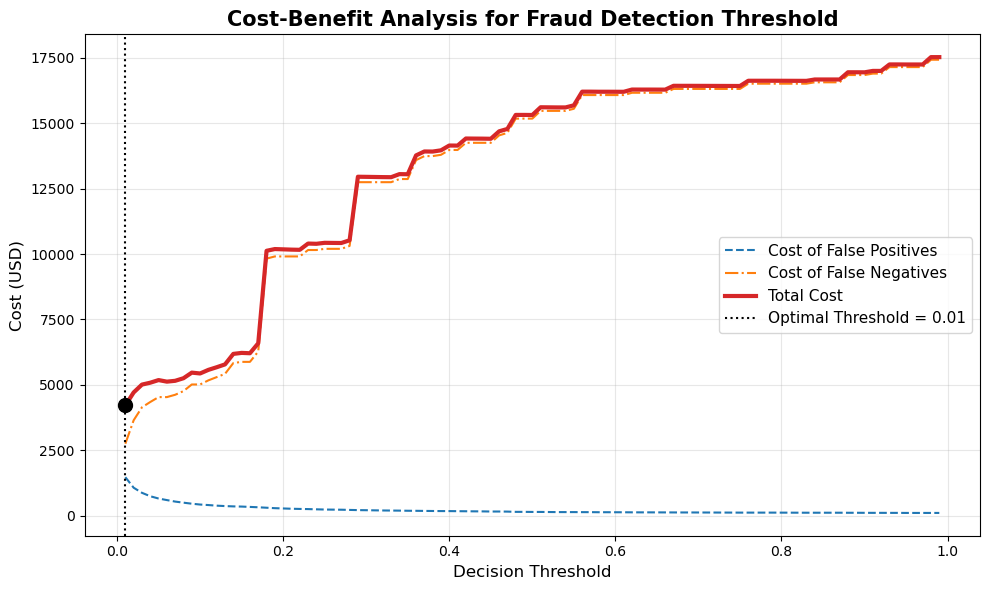

In [110]:
plt.figure(figsize=(10, 6))

plt.plot(df_results['Threshold'], df_results['Cost_FP'], label='Cost of False Positives', color='#1f77b4', linestyle='--')
plt.plot(df_results['Threshold'], df_results['Cost_FN'], label='Cost of False Negatives', color='#ff7f0e', linestyle='-.')
plt.plot(df_results['Threshold'], df_results['Total_Cost'], label='Total Cost', color='#d62728', linewidth=3)

# Đánh dấu điểm đáy
plt.axvline(x=optimal_threshold, color='black', linestyle=':', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.scatter(optimal_threshold, min_cost, color='black', s=100, zorder=5)

plt.title('Cost-Benefit Analysis for Fraud Detection Threshold', fontsize=15, fontweight='bold')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Cost (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Setting up a custom loss function

## 6.1 Create Dynamic Sample Weights

The weights cannot be 5,000 or 10, as XGBoost would experience a "shock" (exploding gradients). We must calculate them based on USD and then normalize them to around the 1.0 level.

In [111]:
# initialize an array of all 1s
train_weights = np.ones(len(y_train), dtype=float)
train_weights[y_train == 0] = C_FP

fraud_mask = (y_train == 1)
train_weights[fraud_mask] = (
    X_train.loc[fraud_mask, 'amount_usd'].to_numpy()
    + FEE_CHARGEBACK
    + FEE_PENALTY
)

# normalization
train_weights = train_weights / np.mean(train_weights)

print("Min weight:", train_weights.min())
print("Max weight:", train_weights.max())

Min weight: 0.4429627500734908
Max weight: 32.151009671594615


## 6.2 Tuning with Optuna with Sample Weights

In [114]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Rất quan trọng khi dùng sample weights
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5), # Giúp chống overfitting
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': 42,
        'n_jobs': -1
    }
    
    tuned_model = xgb.XGBClassifier(**param)
    
    tuned_model.fit(
        X_train, y_train,
        sample_weight=train_weights,
        eval_set=[(X_test, y_test)],
        verbose=False    
    )
    
    preds_prob = tuned_model.predict_proba(X_test)[:, 1]
    
    pr_auc = average_precision_score(y_test, preds_prob)
    
    return pr_auc

In [117]:
# run Optuna Optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("--- BEST RESULT ---")
print(f"Best PR-AUC: {study.best_value}")
print(f"Best param: {study.best_params}")

[I 2026-09-21 13:39:57,845] A new study created in memory with name: no-name-0861825a-f92c-49e4-80a3-d2ea1c59e9e6
[I 2026-09-21 13:39:59,166] Trial 0 finished with value: 0.34874884023085984 and parameters: {'n_estimators': 425, 'learning_rate': 0.012925743622651167, 'max_depth': 7, 'min_child_weight': 7, 'subsample': 0.6858202699211339, 'colsample_bytree': 0.6195183218452093, 'gamma': 3.2815946051639173}. Best is trial 0 with value: 0.34874884023085984.
[I 2026-09-21 13:39:59,838] Trial 1 finished with value: 0.3872511041174498 and parameters: {'n_estimators': 313, 'learning_rate': 0.03817976034833171, 'max_depth': 8, 'min_child_weight': 7, 'subsample': 0.7636577469197471, 'colsample_bytree': 0.6176960403620381, 'gamma': 4.251853372587469}. Best is trial 1 with value: 0.3872511041174498.
[I 2026-09-21 13:40:00,392] Trial 2 finished with value: 0.34203351046611696 and parameters: {'n_estimators': 255, 'learning_rate': 0.026202189635677647, 'max_depth': 6, 'min_child_weight': 6, 'subsam

--- BEST RESULT ---
Best PR-AUC: 0.4026923629311472
Best param: {'n_estimators': 399, 'learning_rate': 0.03171252333311426, 'max_depth': 9, 'min_child_weight': 6, 'subsample': 0.6318515750347731, 'colsample_bytree': 0.7970416066003925, 'gamma': 0.5870661998499633}


In [118]:
# initialize the final model using the best parameters
best_xgb_model = xgb.XGBClassifier(**study.best_params, random_state=42)
best_xgb_model.fit(X_train, y_train, sample_weight=train_weights)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7970416066003925
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 6.3 Re-run model

In [122]:
y_pred_prob_best = best_xgb_model.predict_proba(X_test)[:, 1]

df_eval = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': y_pred_prob_best,
    'amount_usd': X_test['amount_usd'].values
})

thresholds = np.arange(0.01, 1.00, 0.01)
cost_records = []

for t in thresholds:
    # Phân loại dựa trên ngưỡng t
    y_pred_t = (df_eval['y_prob'] >= t).astype(int)
    
    # Tính mask cho False Positive và False Negative
    fp_mask = (df_eval['y_true'] == 0) & (y_pred_t == 1)
    fn_mask = (df_eval['y_true'] == 1) & (y_pred_t == 0)
    
    # TÍNH CHI PHÍ (Viết gộp rất gọn)
    cost_fp = fp_mask.sum() * C_FP
    cost_fn = df_eval.loc[fn_mask, 'amount_usd'].sum() + (fn_mask.sum() * (FEE_CHARGEBACK + FEE_PENALTY))
    
    cost_records.append(cost_fp + cost_fn)
    
optimal_idx = np.argmin(cost_records)
optimal_threshold = thresholds[optimal_idx]
min_total_cost = cost_records[optimal_idx]

y_pred_final = (df_eval['y_prob'] >= optimal_threshold).astype(int)

final_fp = ((df_eval['y_true'] == 0) & (y_pred_final == 1)).sum()
final_fn = ((df_eval['y_true'] == 1) & (y_pred_final == 0)).sum()
cost_fp_final = final_fp * C_FP
cost_fn_final = min_total_cost - cost_fp_final

print("==================================================")
print("              PRODUCTION REPORT                   ")
print("==================================================")
print(f"               Optimal Threshold  : {optimal_threshold:.2f}")
print(f"Minimum Total Risk Cost           : ${min_total_cost:,.2f}")
print("--------------------------------------------------")
print(f"[-] False Positive                : {final_fp} customers -> Damages: ${cost_fp_final:,.2f}")
print(f"[-] False Negative                : {final_fn} fraud scandal -> Damages: ${cost_fn_final:,.2f}")
print("==================================================")

              PRODUCTION REPORT                   
               Optimal Threshold  : 0.18
Minimum Total Risk Cost           : $10,904.72
--------------------------------------------------
[-] False Positive                : 28 customers -> Damages: $2,800.00
[-] False Negative                : 42 fraud scandal -> Damages: $8,104.72


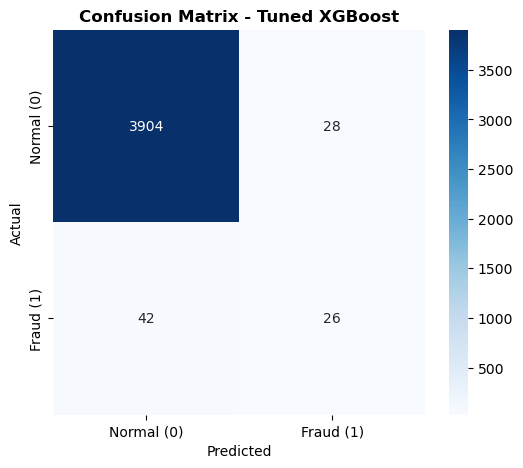

In [124]:
tuned_cm = confusion_matrix(df_eval['y_true'], y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(tuned_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Tuned XGBoost', fontweight='bold')
plt.show()

In [125]:
print(classification_report(df_eval['y_true'], y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3932
           1       0.48      0.38      0.43        68

    accuracy                           0.98      4000
   macro avg       0.74      0.69      0.71      4000
weighted avg       0.98      0.98      0.98      4000

